In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("MNIST downloaded")
print(len(train_data), len(test_data))

MNIST downloaded
60000 10000


In [3]:
def get_subset(dataset, classes):
    indices = []

    for i in range(len(dataset)):
        _, label = dataset[i]
        if label in classes:
            indices.append(i)

    return Subset(dataset, indices)


taskA_train = get_subset(train_data, [0, 1, 2, 3, 4])
taskA_test  = get_subset(test_data,  [0, 1, 2, 3, 4])

taskB_train = get_subset(train_data, [5, 6, 7, 8, 9])
taskB_test  = get_subset(test_data,  [5, 6, 7, 8, 9])

print("Task A train:", len(taskA_train))
print("Task B train:", len(taskB_train))

Task A train: 30596
Task B train: 29404


In [4]:
batch_size = 128

taskA_train_loader = DataLoader(taskA_train, batch_size=batch_size, shuffle=True)
taskA_test_loader  = DataLoader(taskA_test,  batch_size=batch_size, shuffle=False)

taskB_train_loader = DataLoader(taskB_train, batch_size=batch_size, shuffle=True)
taskB_test_loader  = DataLoader(taskB_test,  batch_size=batch_size, shuffle=False)

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)


model = MLP().to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
def train(model, loader, epochs=2, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)
            loss = criterion(output, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

In [7]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            output = model(x)
            pred = torch.argmax(output, dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

In [8]:
print("Training on Task A: digits 0-4")
train(model, taskA_train_loader, epochs=2)

taskA_acc_before = evaluate(model, taskA_test_loader)
taskB_acc_before = evaluate(model, taskB_test_loader)

print(f"Task A Accuracy Before Task B: {taskA_acc_before:.2f}%")
print(f"Task B Accuracy Before Task B: {taskB_acc_before:.2f}%")

Training on Task A: digits 0-4


Epoch 1/2, Loss: 0.2183


Epoch 2/2, Loss: 0.0743


Task A Accuracy Before Task B: 98.33%
Task B Accuracy Before Task B: 0.00%


In [9]:
print("Training on Task B: digits 5-9")
train(model, taskB_train_loader, epochs=2)

taskB_acc_after = evaluate(model, taskB_test_loader)
taskA_acc_after = evaluate(model, taskA_test_loader)

print(f"Task B Accuracy After Training: {taskB_acc_after:.2f}%")
print(f"Task A Accuracy After Task B: {taskA_acc_after:.2f}%")

Training on Task B: digits 5-9


Epoch 1/2, Loss: 0.8174


Epoch 2/2, Loss: 0.1464


Task B Accuracy After Training: 96.30%
Task A Accuracy After Task B: 0.00%


In [10]:
baseline_forgetting = taskA_acc_before - taskA_acc_after
forgetting = baseline_forgetting

print("Result ")
print(f"Task A Accuracy Before Task B: {taskA_acc_before:.2f}%")
print(f"Task A Accuracy After Task B: {taskA_acc_after:.2f}%")
print(f"Baseline Catastrophic Forgetting: {baseline_forgetting:.2f}%")

Result 
Task A Accuracy Before Task B: 98.33%
Task A Accuracy After Task B: 0.00%
Baseline Catastrophic Forgetting: 98.33%


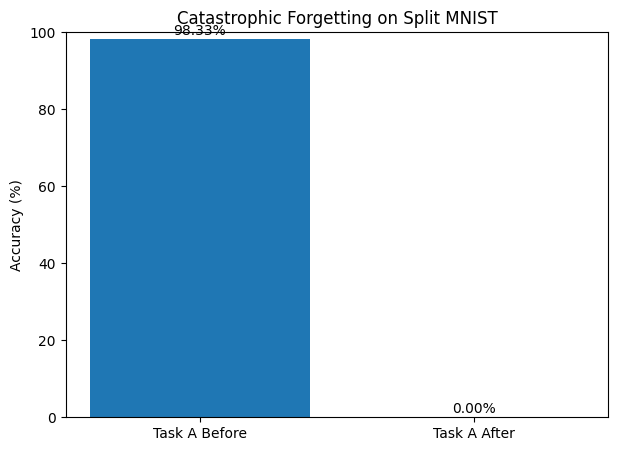

In [11]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Task A Before", "Task A After"],
    [taskA_acc_before, taskA_acc_after]
)

plt.ylabel("Accuracy (%)")
plt.title("Catastrophic Forgetting on Split MNIST")
plt.ylim(0, 100)

for i, acc in enumerate([taskA_acc_before, taskA_acc_after]):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha="center")

plt.show()

In [12]:
print(taskA_acc_before)
print(taskA_acc_after)
print(taskB_acc_after)
print(model)
print(taskA_train_loader)
print(taskB_train_loader)

98.32652266978012
0.0
96.29705821847357
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [13]:
replay_model = MLP().to(device)

print("Replay model created")

Replay model created


In [14]:
train(
    replay_model,
    taskA_train_loader,
    epochs=2
)

replay_taskA_before = evaluate(
    replay_model,
    taskA_test_loader
)

print(
    "Task A Accuracy:",
    replay_taskA_before
)

Epoch 1/2, Loss: 0.2132


Epoch 2/2, Loss: 0.0769


Task A Accuracy: 98.50165401829149


In [15]:
MEMORY_SIZE = 500

memory_x = []
memory_y = []

count = 0

for x, y in taskA_train_loader:

    for i in range(len(x)):

        memory_x.append(x[i])
        memory_y.append(y[i])

        count += 1

        if count >= MEMORY_SIZE:
            break

    if count >= MEMORY_SIZE:
        break

memory_x = torch.stack(memory_x)
memory_y = torch.tensor(memory_y)

print(memory_x.shape)

torch.Size([500, 1, 28, 28])


In [16]:
def train_with_replay(
    model,
    task_loader,
    memory_x,
    memory_y,
    epochs=2
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    for epoch in range(epochs):

        for x_new, y_new in task_loader:

            x_new = x_new.to(device)
            y_new = y_new.to(device)

            idx = torch.randint(
                0,
                len(memory_x),
                (len(x_new),)
            )

            x_mem = memory_x[idx].to(device)
            y_mem = memory_y[idx].to(device)

            x = torch.cat(
                [x_new, x_mem],
                dim=0
            )

            y = torch.cat(
                [y_new, y_mem],
                dim=0
            )

            optimizer.zero_grad()

            output = model(x)

            loss = criterion(
                output,
                y
            )

            loss.backward()

            optimizer.step()

        print(
            f"Epoch {epoch+1} done"
        )

In [17]:
train_with_replay(
    replay_model,
    taskB_train_loader,
    memory_x,
    memory_y,
    epochs=2
)

Epoch 1 done


Epoch 2 done


In [18]:
replay_taskA_after = evaluate(
    replay_model,
    taskA_test_loader
)

replay_taskB_after = evaluate(
    replay_model,
    taskB_test_loader
)

replay_forgetting = replay_taskA_before - replay_taskA_after

print(
    "Task A Before:",
    replay_taskA_before
)

print(
    "Task A After Replay:",
    replay_taskA_after
)

print(
    "Replay Forgetting:",
    replay_forgetting
)

print(
    "Task B Accuracy:",
    replay_taskB_after
)

Task A Before: 98.50165401829149
Task A After Replay: 89.62833236038139
Replay Forgetting: 8.873321657910097
Task B Accuracy: 95.28903517794693


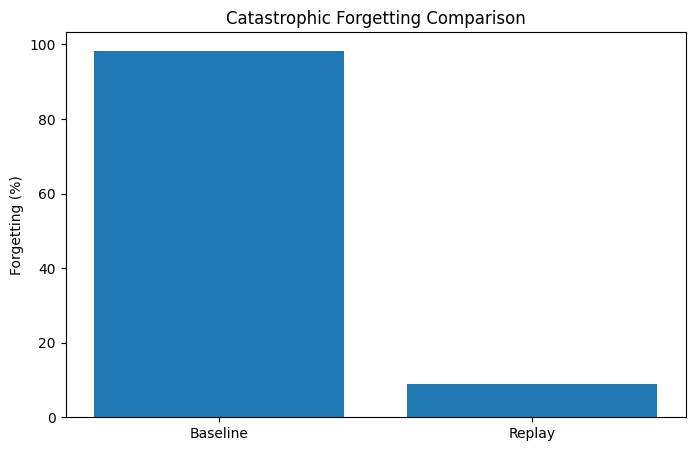

In [19]:
plt.figure(figsize=(8,5))

methods = [
    "Baseline",
    "Replay"
]

forget_values = [
    baseline_forgetting,
    replay_forgetting
]

plt.bar(
    methods,
    forget_values
)

plt.ylabel("Forgetting (%)")
plt.title("Catastrophic Forgetting Comparison")

plt.show()

In [20]:
agem_model=MLP().to(device)
print('Agem model initialized.')

Agem model initialized.


In [21]:
train(
       agem_model,
       taskA_train_loader,
       epochs=2
)
agem_taskA_before=evaluate(
       agem_model,
       taskA_test_loader
)
print('Agem Task A Accuracy before Task B:', agem_taskA_before)

Epoch 1/2, Loss: 0.2149


Epoch 2/2, Loss: 0.0776


Agem Task A Accuracy before Task B: 98.71570344424985


In [22]:
AGEM_MEMORY_SIZE = 500
agem_memory_x = []
agem_memory_y = []

count=0 
for x,y in taskA_train_loader:
       for i in range(len(x)):
              agem_memory_x.append(x[i])
              agem_memory_y.append(y[i])
              count+=1
              if count>=AGEM_MEMORY_SIZE:
                     break
       if count>=AGEM_MEMORY_SIZE:
              break

agem_memory_x= torch.stack(agem_memory_x)
agem_memory_y= torch.tensor(agem_memory_y)
print(agem_memory_x.shape, agem_memory_y.shape)

torch.Size([500, 1, 28, 28]) torch.Size([500])


In [23]:
def get_grad_vector(model):
       grads=[]

       for param in model.parameters():
              if param.grad is not None:
                     grads.append(param.grad.view(-1))
       return torch.cat(grads)
              
def set_grad_vector(model,grad_vector):
       pointer=0 

       for param in model.parameters():
              if param.grad is not None:
                     num_params=param.numel()
                     param.grad.copy_(grad_vector[pointer:pointer+num_params].view_as(param))
                     pointer+=num_params

In [24]:
def train_with_agem(
       model,
       task_loader,
       memory_x,
       memory_y,
       epochs=2,
       lr=0.001,
       memory_batch_size=128
):
       criterion=nn.CrossEntropyLoss()
       optimizer=optim.Adam(model.parameters(), lr=lr)
       model.train()

       for epoch in range(epochs):
              train_loss=0
              conflict_count=0
              for x_new,y_new in task_loader:
                     x_new=x_new.to(device)
                     y_new=y_new.to(device)
                     optimizer.zero_grad()
                     outputs=model(x_new)
                     loss_new=criterion(outputs, y_new)
                     loss_new.backward()
                     g=get_grad_vector(model)

                     idx=torch.randint(0, len(memory_x), (memory_batch_size,))
                     x_mem=memory_x[idx].to(device)
                     y_mem=memory_y[idx].to(device)
                     optimizer.zero_grad()
                     outputs_mem=model(x_mem)
                     loss_mem=criterion(outputs_mem, y_mem)
                     loss_mem.backward()
                     g_ref=get_grad_vector(model)
                     dot_product=torch.dot(g,g_ref)

                     if dot_product <0 :
                            conflict_count += 1 
                            g_projected=g-(dot_product/torch.dot(g_ref,g_ref))*g_ref
                     else :
                            g_projected= g



                     optimizer.zero_grad()
                     output_new=model(x_new)
                     loss_new=criterion(output_new,y_new)


                     loss_new.backward()
                     set_grad_vector(model, g_projected)
                     optimizer.step()
                     train_loss+= loss_new.item()

              print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(task_loader):.4f}, Conflicts: {conflict_count}")


               
       


In [25]:
train_with_agem(agem_model,
                taskB_train_loader,
       agem_memory_x,
       agem_memory_y,
       epochs=2,
       memory_batch_size=128
)

Epoch 1/2, Loss: 0.8219, Conflicts: 217


Epoch 2/2, Loss: 0.1354, Conflicts: 191


In [36]:
agem_taskA_after=evaluate(
       agem_model,
       taskA_test_loader)
agem_taskB_after=evaluate(
       agem_model,taskB_test_loader)
agem_forgetting=(agem_taskA_before-agem_taskA_after)


print(f"Agem Task A Before: {agem_taskA_before:.2f}%")
print(f"Agem Task A After: {agem_taskA_after:.2f}%")
print(f"Agem Task B After: {agem_taskB_after:.2f}%")
print(f"Agem Forgetting: {agem_forgetting:.2f}%")


Agem Task A Before: 98.95%
Agem Task A After: 98.95%
Agem Task B After: 0.00%
Agem Forgetting: 0.00%


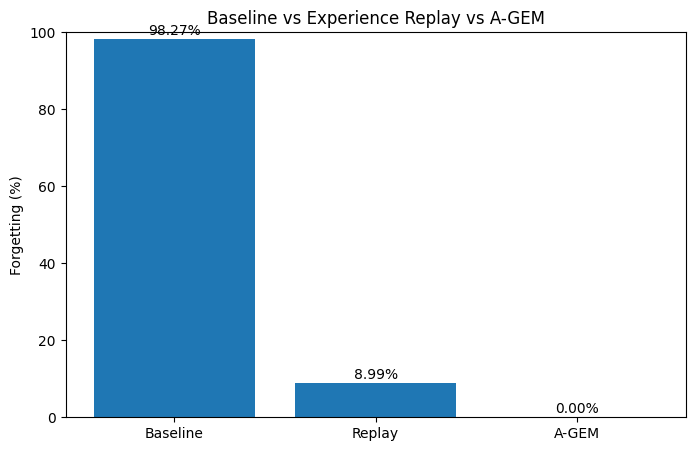

In [37]:
baseline_forgetting = taskA_acc_before - taskA_acc_after
replay_forgetting = replay_taskA_before - replay_taskA_after
agem_forgetting = agem_taskA_before - agem_taskA_after

methods = [
    "Baseline",
    "Replay",
    "A-GEM"
]

forgetting_values = [
    baseline_forgetting,
    replay_forgetting,
    agem_forgetting
]

plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    forgetting_values
)

plt.ylabel("Forgetting (%)")
plt.title("Baseline vs Experience Replay vs A-GEM")

for i, value in enumerate(forgetting_values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.show()

In [38]:
print("Task A Before :", agem_taskA_before)
print("Task A After  :", agem_taskA_after)
print("Task B After  :", agem_taskB_after)
print("Forget        :", agem_forgetting)

Task A Before : 98.9492119089317
Task A After  : 98.9492119089317
Task B After  : 0.0
Forget        : 0.0
